## 1. Data Preprocessing
In this section, we import the raw ESS data and prepare it for analysis by handling missing values and transforming variables.

In [154]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn.external.docscrape import header

# Load Dataset
zip_path = "ESS9e03_3-ESS10e03_3-ESS10SCe03_2-ESS11e04_1-subset.zip"
csv_inside = "ESS9e03_3-ESS10e03_3-ESS10SCe03_2-ESS11e04_1-subset.csv"

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(csv_inside) as f:
        df = pd.read_csv(f, low_memory=False)

print("CSV Load Successful!")
print(f"Dataset Size: {df.shape[0]} rows x {df.shape[1]} columns")

CSV Load Successful!
Dataset Size: 159320 rows x 635 columns


### Data Exploration
The original ESS dataset contains hundreds of variables. For this study, we have isolated 34 specific variables categorized into:

Demographics: yrbrn, agea, gndr, etc.

Schwartz Human Values: The 21-item battery (e.g., ipcrtiv to ipadvnt).

Socio-Political Attitudes: gincdif (Redistribution) and Institutional Trust (trstplt).

In [155]:
df.columns

Index(['name', 'essround', 'edition', 'proddate', 'idno', 'cntry', 'dweight',
       'pspwght', 'pweight', 'anweight',
       ...
       'inwdde', 'inwmme', 'inwde', 'jinws', 'jinwe', 'scwd78se', 'questcmp',
       'intewde', 'mode', 'yrbrn'],
      dtype='object', length=635)

In [156]:
columns_to_keep = [
    "idno","cntry","essround","yrbrn","agea","gndr","anweight",
    "lrscale","trstprl","trstplt","trstlgl","stflife","gincdif",
    "ipcrtiv","imprich","impfun","impsafe","imptrad","impfree",
    "impenv","iphlppl","ipeqopt","ipudrst","ipgdtim","ipfrule",
    "ipstrgv","ipbhprp","iplylfr","ipmodst","iprspot","ipsuces",
    "ipadvnt","impdiff","ipshabt"]

In [157]:
datacol = df[columns_to_keep]

In [158]:
datacol.to_csv("filtered_columns.csv", index=False)

In [159]:
df = pd.read_csv("filtered_columns.csv")
print(df.head())

   idno cntry  essround  yrbrn  agea  gndr  anweight  lrscale  trstprl  \
0    27    AT         9   1975    43     1  0.065890        9        5   
1   137    AT         9   1951    67     1  0.124907        5        7   
2   194    AT         9   1978    40     2  0.685836        5        6   
3   208    AT         9   1955    63     1  0.116753       88        0   
4   220    AT         9   1947    71     2  0.311789        5        7   

   trstplt  ...  ipfrule  ipstrgv  ipbhprp  iplylfr  ipmodst  iprspot  \
0        5  ...      2.0      2.0      2.0      2.0      1.0      2.0   
1        3  ...      4.0      3.0      2.0      2.0      4.0      3.0   
2        5  ...      3.0      2.0      2.0      3.0      3.0      3.0   
3        3  ...      2.0      1.0      1.0      1.0      2.0      1.0   
4        7  ...      2.0      2.0      1.0      2.0      3.0      3.0   

   ipsuces  ipadvnt  impdiff  ipshabt  
0      2.0      2.0      2.0      2.0  
1      4.0      5.0      4.0      3.

### Data Cleansing
To ensure the data is research-ready, we perform the following:
1. **Checked for duplicates**
2. **Checked Missing Values:** Convert ESS codes (7, 8, 9, 77, 88, 99) to `NaN`.
3. **Scale Reversal:** We transform the 1- 6 scale to ensure **6 = Strong Agreement**.


#### 1. Checked for duplicates

In [160]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
159315    False
159316    False
159317    False
159318    False
159319    False
Length: 159320, dtype: bool

In [161]:
df.isna().sum()

idno            0
cntry           0
essround        0
yrbrn           0
agea            0
gndr            0
anweight        0
lrscale         0
trstprl         0
trstplt         0
trstlgl         0
stflife         0
gincdif         0
ipcrtiv     72190
imprich     72190
impfun      72190
impsafe     72190
imptrad     72190
impfree     72190
impenv      72190
iphlppl     72190
ipeqopt     72190
ipudrst     72190
ipgdtim     72190
ipfrule     72190
ipstrgv     72190
ipbhprp     72190
iplylfr     72190
ipmodst     72190
iprspot     72190
ipsuces     72190
ipadvnt     72190
impdiff     72190
ipshabt     72190
dtype: int64

All value variables (ipcrtiv, imprich, impfun, ...) have 72190 NaN

This usually happens in ESS when you merged rounds OR loaded multiple rounds in one file
because Schwartz values are NOT asked in every round.

So this is normal, not an error.

#### 2. Checked Missing Values

In [162]:
# Handle Missing Data for left-right scale
df = df [(df["lrscale"] >= 0)  & (df["lrscale"] <= 10)]

# Handle missing data for Income redistribution
df['gincdif'] = df['gincdif'].replace([7, 8, 9, 77, 88, 99], np.nan)

# #Handle missing data for satisfaction with life as a whole
df['stflife'] = df['stflife'].replace([7, 8, 9], np.nan)

#Handle missing values for Trust in Parliament
df['trstprl'] = df['trstprl'].replace([7, 8, 9], np.nan)

# Handle missing values for Gender
df['gndr'] = df['gndr'].replace(9, np.nan)


In [163]:
df["lrscale"].unique()
df["gincdif"].unique()

array([ 1.,  2.,  3.,  4.,  5., nan])

#### 3. Scale Reversal

In [164]:
# Reverse Coding (7 - x) for Irscale Items (ip... and imp... columns)
#Identify the columns
value_cols = [c for c in df.columns if c.startswith('ip') or c.startswith('imp')]
# Convert 'Refusals' (7), 'Don't Knows' (8), and 'No Answers' (9) to NaN
# This ensures they don't mess up our averages
for col in value_cols:
    df.loc[df[col] > 6, col] = np.nan

# apply the Reverse Coding: 7 - x
# Now 6 = "Very much like me" and 1 = "Not like me at all"
df[value_cols] = 7 - df[value_cols]

# Reversing gincdif (1-5 scale)
# Original: 1 = Agree Strongly, 5 = Disagree Strongly
# New: 5 = Agree Strongly, 1 = Disagree Strongly
df['gincdif'] = 6 - df['gincdif']

### Variable Transformation
1. **Generational Mapping ** (Gen Z to Boomers) based on `yrbrn`
2. **Schwartz Dimensions:** Mapping 21 items into the 10 core values.
3. **MRAT Correction**

#### 1. Generational Mapping

In [165]:
# Select the years of birth between 1920-2010
df = df [(df["yrbrn"] >= 1920) & (df["yrbrn"] <= 2010)]

In [166]:
df["yrbrn"].unique()

array([1975, 1951, 1978, 1947, 1954, 1962, 1944, 1981, 1996, 1970, 1959,
       1941, 1977, 1956, 1991, 1958, 1969, 1976, 1968, 1988, 1999, 1948,
       1972, 1983, 1982, 1995, 1950, 1960, 1974, 1946, 1945, 1973, 1985,
       1979, 1971, 1980, 1942, 1965, 1993, 1940, 1961, 2000, 1986, 1989,
       1964, 1992, 1955, 1963, 1994, 1949, 1943, 1939, 1966, 1957, 1984,
       1987, 1932, 1952, 1933, 1997, 1953, 2001, 1990, 1931, 1936, 1928,
       1935, 1998, 2002, 1967, 1938, 1934, 2003, 1937, 1930, 1929, 2004,
       2006, 2005, 2007, 2008, 2009])

In [167]:
# Create Generation Column
conditions = [
    (df['yrbrn'] >= 1997),                                # Gen Z
    (df['yrbrn'] >= 1981) & (df['yrbrn'] <= 1996),        # Millennials
    (df['yrbrn'] >= 1965) & (df['yrbrn'] <= 1980),        # Gen X
    (df['yrbrn'] >= 1946) & (df['yrbrn'] <= 1964),        # Boomers
    (df['yrbrn'] <= 1945)                                 # Silent Generation
]

labels = ['Gen Z', 'Millennials', 'Gen X', 'Boomers', 'Silent Gen']
df['generation'] = np.select(conditions, labels, default='Unknown')

print(df['generation'].value_counts())


generation
Boomers        43747
Gen X          36956
Millennials    29632
Silent Gen     13194
Gen Z          12925
Name: count, dtype: int64


#### 2. Schwartz Dimensions

In [168]:
# Creating new columns for Schwartz Value Dimensions ---

# Universalism: Understanding, Helping, Environment
df['Universalism'] = df[['ipudrst', 'ipeqopt', 'impenv']].mean(axis=1)

# Benevolence: Helping, Loyalty to friends
df['Benevolence'] = df[['iphlppl', 'iplylfr']].mean(axis=1)


# Tradition: Modesty, Tradition
df['Tradition'] = df[['imptrad', 'ipmodst']].mean(axis=1)

# Security: Safety, Strong Government
df['Security'] = df[['impsafe', 'ipstrgv']].mean(axis=1)

# Conformity: Following rules, Behaving properly
df['Conformity'] = df[['ipfrule', 'ipbhprp']].mean(axis=1)

# Self-Direction: Freedom, Creativity
df['Self-Direction'] = df[['impfree', 'ipcrtiv']].mean(axis=1)

# Stimulation: Excitement, Adventure (Now using BOTH variables)
df['Stimulation'] = df[['ipadvnt', 'impdiff']].mean(axis=1)

# Hedonism: Good times, Fun
df['Hedonism'] = df[['ipgdtim', 'impfun']].mean(axis=1)

# Achievement: Success, Ability, and Equality
df['Achievement'] = df[['ipsuces', 'ipshabt']].mean(axis=1)

# Power: Wealth, Respect
df['Power'] = df[['imprich', 'iprspot']].mean(axis=1)

print("âœ… All 10 dimensions calculated! The mapping now includes the newly added variables.")

âœ… All 10 dimensions calculated! The mapping now includes the newly added variables.


In [169]:
# Create the List for the names of the new Schwartz values columns
schwartz_values = [
    'Universalism', 'Benevolence', 'Tradition', 'Security',
    'Conformity', 'Self-Direction', 'Stimulation', 'Hedonism',
    'Achievement', 'Power'
]

In [170]:
# 5. Cleaned Data Preview for the team
print("\n### Cleaned Data Preview")
display(df[['generation', 'lrscale'] + schwartz_values].head())


### Cleaned Data Preview


,generation,lrscale,Universalism,Benevolence,Tradition,Security,Conformity,Self-Direction,Stimulation,Hedonism,Achievement,Power
0,Gen X,9,4.333333,5.0,5.5,5.0,5.0,5.5,5.0,4.5,5.0,5.0
1,Boomers,5,4.000000,4.5,3.5,4.5,4.0,4.0,2.5,4.0,3.5,3.5
2,Gen X,5,4.000000,4.5,4.0,4.0,4.5,4.5,3.5,3.5,4.0,3.0
4,Boomers,5,5.333333,5.0,5.0,5.0,5.5,5.0,2.0,4.5,2.0,2.5
5,Boomers,3,6.000000,6.0,6.0,5.0,4.5,4.5,4.0,6.0,4.5,3.0


#### 3. MRAT (Mean Rating) Correction.

1. calculate the average score each person gave across all 21 original items. 

In [171]:
# Hardcode the exact 21 ESS PVQ-21 items
mrat_items = [
    'ipudrst', 'ipeqopt', 'impenv', 'iphlppl', 'iplylfr',
    'imptrad', 'ipmodst', 'impsafe', 'ipstrgv', 'ipfrule',
    'ipbhprp', 'impfree', 'ipcrtiv', 'ipadvnt', 'impdiff',
    'ipgdtim', 'impfun', 'ipsuces', 'ipshabt', 'imprich', 'iprspot'
]

# Calculate the MRAT score
df['mrat_score'] = df[mrat_items].mean(axis=1)


2. Apply the MRAT Correction (Centering)

In [172]:
# Apply the Correction: Dimension - MRAT
for item in mrat_items:
    df[f'{item}_centered'] = df[item] - df['mrat_score']

# Group the centered items into the 10 Schwartz Dimensions 
df['Universalism_centered'] = df[['ipudrst_centered', 'ipeqopt_centered', 'impenv_centered']].mean(axis=1)
df['Benevolence_centered'] = df[['iphlppl_centered', 'iplylfr_centered']].mean(axis=1)
df['Tradition_centered'] = df[['imptrad_centered', 'ipmodst_centered']].mean(axis=1)
df['Security_centered'] = df[['impsafe_centered', 'ipstrgv_centered']].mean(axis=1)
df['Conformity_centered'] = df[['ipfrule_centered', 'ipbhprp_centered']].mean(axis=1)
df['Self-Direction_centered'] = df[['impfree_centered', 'ipcrtiv_centered']].mean(axis=1)
df['Stimulation_centered'] = df[['ipadvnt_centered', 'impdiff_centered']].mean(axis=1)
df['Hedonism_centered'] = df[['ipgdtim_centered', 'impfun_centered']].mean(axis=1)
df['Achievement_centered'] = df[['ipsuces_centered', 'ipshabt_centered']].mean(axis=1)
df['Power_centered'] = df[['imprich_centered', 'iprspot_centered']].mean(axis=1)


3. Check the MRAT (Mean Rating) Correction by performing three validation

A. Mathematical Integrity (Row-wise Check)

In [173]:
# Verify that the centering worked by checking the sum of centered values for one respondent
centered_items = [f'{item}_centered' for item in mrat_items]
row_sum = df[centered_items].iloc[0].sum()

print(f"Correct sum (items): {row_sum:.15f}")



Correct sum (items): -0.000000000000004


The result is exactly zero. When we find the average of a group of numbers, and then subtract that average from every single number, adding them all back together must equal zero. So, it proves MRAT formula was 100% correct.

B. Manual Spot Check (Directional Accuracy)

In [174]:
# Create a verification table
check_df = df[['Universalism', 'mrat_score', 'Universalism_centered']].head(5)

print("### MRAT Verification (Universalism - mrat_score = Universalism_centered)")
print(check_df)

# LOGIC: 
# If Universalism (e.g. 5.2) > mrat_score (e.g. 4.0), 
# then Universalism_centered MUST be positive (e.g. 1.2).

### MRAT Verification (Universalism - mrat_score = Universalism_centered)
   Universalism  mrat_score  Universalism_centered
0      4.333333    4.952381              -0.619048
1      4.000000    3.809524               0.190476
2      4.000000    3.952381               0.047619
4      5.333333    4.238095               1.095238
5      6.000000    5.000000               1.000000


Respondent 5: Raw Universalism (6.0) - MRAT (5.0) = Centered (+1.0)
Respondent 0: Raw Universalism (4.33) - MRAT (4.95) = Centered (-0.62)
This confirms that a positive centered score correctly identifies a "High Priority" relative to the individual's average, even if their raw scores were generally high (Yeasaying bias).

C. Conceptual Check (Distribution Analysis)

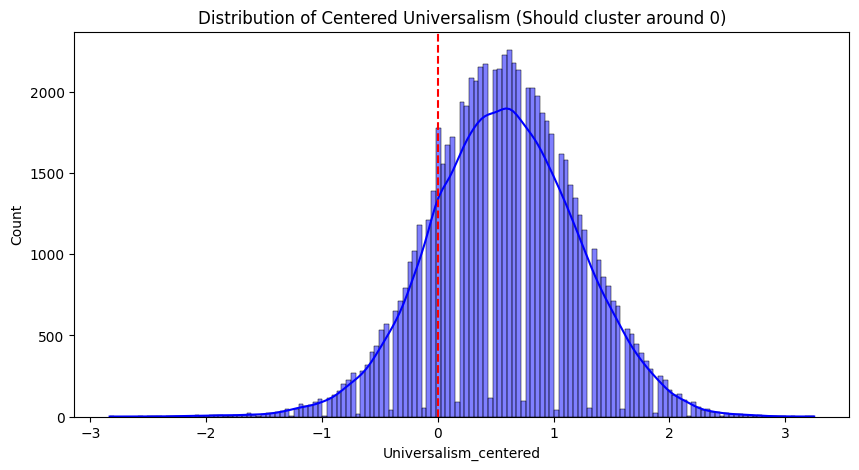

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['Universalism_centered'], kde=True, color='blue', label='Centered')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Centered Universalism (Should cluster around 0)')
plt.show()

The histogram for Universalism_centered shows a healthy normal distribution ranging from approximately -3 to +3, with a peak (mode) shifted slightly to the right of zero (~0.5).
This tells us that most people in Europe score "Universalism" slightly higher than their own personal average.

Create the Master Analysis File

In [176]:
# 1.Define the specific columns we want to keep for the final analysis
analysis_columns = [
    'essround', 'generation', 'yrbrn', 'lrscale', 'stflife', 'trstprl', 'gincdif', 'mrat_score'
] + [f'{v}_centered' for v in schwartz_values]

# Save to your final analysis file
df[analysis_columns].to_csv("ess_final_analysis.csv", index=False)
print("✅ Master Analysis File Saved: 'ess_final_analysis.csv'")


✅ Master Analysis File Saved: 'ess_final_analysis.csv'


## 2. Descriptive Analysis

### 1. Sample Composition (Demographics)
We would like to show the distribution of the respondents to tell how many people from each generation are represented.

C:\Users\Tayami\AppData\Local\Temp\ipykernel_16420\1275408843.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='generation', palette='viridis', order=gen_order)


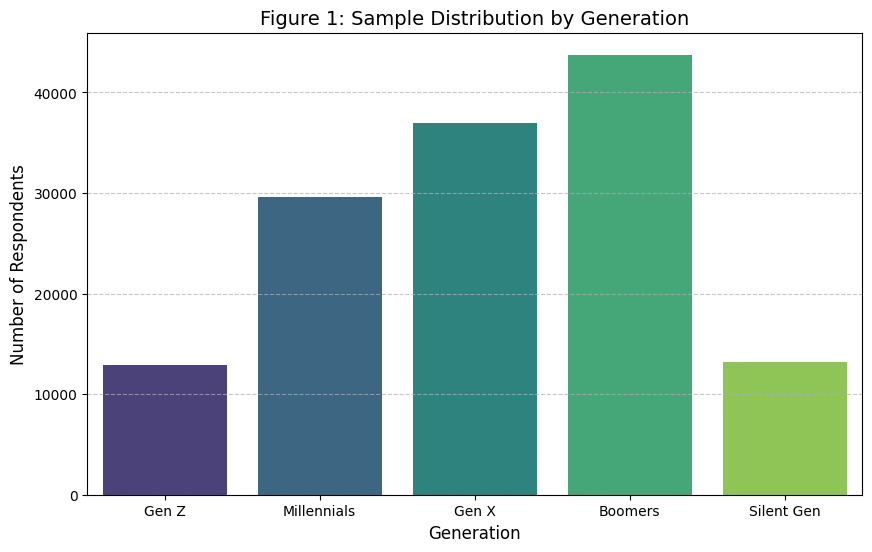

Value Counts for Generations:
generation
Boomers        43747
Gen X          36956
Millennials    29632
Silent Gen     13194
Gen Z          12925
Name: count, dtype: int64


In [177]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the order for consistent plotting
gen_order = ['Gen Z', 'Millennials', 'Gen X', 'Boomers', 'Silent Gen']

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='generation', palette='viridis', order=gen_order)

plt.title('Figure 1: Sample Distribution by Generation', fontsize=14)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print counts to check the 'Unknown' category
print("Value Counts for Generations:")
print(df['generation'].value_counts())

### 2. The Generational Value Heatmap (MRAT Corrected)

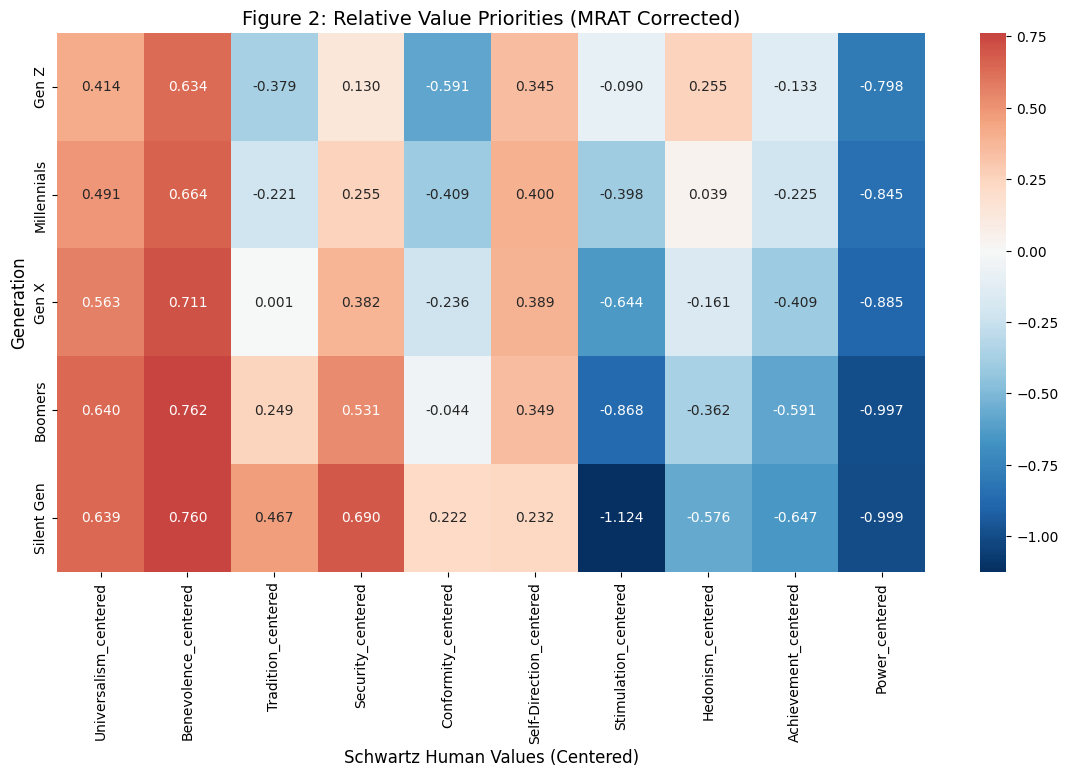

In [178]:
# List of the 10 centered columns we created earlier
centered_cols = [f'{v}_centered' for v in schwartz_values]

# Calculate the mean for your 5 generations
gen_means = df.groupby('generation')[centered_cols].mean().reindex(gen_order)

plt.figure(figsize=(14, 7))
sns.heatmap(gen_means, annot=True, cmap='RdBu_r', center=0, fmt=".3f")

plt.title('Figure 2: Relative Value Priorities (MRAT Corrected)', fontsize=14)
plt.xlabel('Schwartz Human Values (Centered)', fontsize=12)
plt.ylabel('Generation', fontsize=12)
plt.show()

Figure 2 illustrates the relative value priorities across five generational cohorts using MRAT-corrected scores. 
A clear generational divide is visible in the Conservation values; specifically, Tradition and Security show a linear increase in priority from Gen Z to the Silent Generation. 
Conversely, Stimulation—representing an openness to novelty—is significantly less prioritized by older cohorts (Silent Gen: -1.124) compared to younger ones. 
Interestingly, Universalism remains a positive priority for all groups, though its relative weight is highest among the Silent Generation and Boomers in this sample.